# Session 6 - Regression Analysis (Used Cars)
In this session we build linear regression models to estimate used car prices from mileage, age, and power, then store predicted prices for downstream use.


## Learning objectives
- Understand why we scope analysis to a single make/model combination.
- Fit and interpret univariate and multivariate linear regression models.
- Explain coefficients with clear units and interpret R^2, MAE, and RMSE.
- Distinguish confidence intervals for the mean from prediction intervals for new observations.
- Store predicted prices from the multivariate model in BigQuery.


## Environment setup (installations)

Before running the notebook, install the required Python packages in the same environment as the notebook kernel.

Minimum required packages:
- `google-cloud-bigquery`
- `db-dtypes`
- `pandas`
- `matplotlib`
- `scikit-learn`
- `statsmodels`

Recommended one-liner (includes the pandas extras for BigQuery):
```bash
pip install "google-cloud-bigquery[pandas]" db-dtypes pandas matplotlib scikit-learn statsmodels pyarrow
```

If you are using the `.venv` from this repo, run:
```powershell
.\.venv\Scripts\python.exe -m pip install "google-cloud-bigquery[pandas]" db-dtypes pandas matplotlib scikit-learn statsmodels pyarrow
```

---


## Step 0 - Imports and environment checks

We set project variables, import libraries, and create output folders.


In [1]:
# Core
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# BigQuery
from google.cloud import bigquery

# Statsmodels (needed for prediction intervals)

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# BigQuery settings (align with Session 4 SQL notebook)
project_id = 'albertheadofdata101'  # Replace if your project is different
dataset_id = 'autoscout_audi_a3_germany'

# Output folders (always anchored at project root)
def find_project_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / ".git").exists():
            return p
    return start

PROJECT_ROOT = find_project_root(Path.cwd())

DATA_RAW_DIR = PROJECT_ROOT / "data/raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data/processed"
REPORTS_DIR = PROJECT_ROOT / "docs"

for p in [DATA_RAW_DIR, DATA_PROCESSED_DIR, REPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Project root: c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101


## Step 1 - Connect to BigQuery (ADC) and quick test

We use Application Default Credentials (ADC). The quick test verifies connectivity and counts rows in the fact table.


In [2]:
# Create a BigQuery client (uses Application Default Credentials)
client = bigquery.Client(project=project_id)

# Helper: run a SQL query and return a DataFrame
def run_query(sql):
    return client.query(sql).to_dataframe()

# Quick connectivity check
sql_test = f"""
SELECT COUNT(*) AS n
FROM `{project_id}.{dataset_id}.fact_listings`
"""

print(run_query(sql_test))


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\auth\_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


      n
0  3380


## Step 2 - Define SQL queries (top scope + modeling dataset)

We first find the most common (make, model, listing_country) combination after basic filtering. Then we pull only the columns needed for modeling.


In [3]:
sql_top_scope = f"""
SELECT
  dm.make AS make,
  dm.model AS model,
  COUNT(*) AS n_records
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_model` AS dm
  ON fl.model_id = dm.model_id
WHERE
  fl.price_eur IS NOT NULL AND fl.price_eur > 0
  AND fl.mileage_km IS NOT NULL AND fl.mileage_km > 0
  AND fl.age_years IS NOT NULL AND fl.age_years >= 0
  AND fl.power_hp IS NOT NULL AND fl.power_hp > 0
GROUP BY make, model
ORDER BY n_records DESC
LIMIT 1
"""


In [4]:
# Pick the most common make/model scope for modeling
top_scope = run_query(sql_top_scope)

make = top_scope.loc[0, "make"]
model = top_scope.loc[0, "model"]
print(f"Scoped to: {make} / {model}")


Scoped to: audi / a3


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


## Step 3 - Load data into pandas and validate

Why do we scope to one make/model?
- Prices depend strongly on make, model, and local market.
- Focusing on a single scope reduces confounding and yields a cleaner baseline.
- It keeps the regression interpretable for beginners.


In [5]:
# Build the modeling query for the selected scope
sql_modeling = f"""
SELECT
  fl.listing_id,
  fl.price_eur,
  fl.mileage_km,
  fl.age_years,
  fl.power_hp,
  dm.make,
  dm.model
FROM `{project_id}.{dataset_id}.fact_listings` AS fl
JOIN `{project_id}.{dataset_id}.dim_model` AS dm
  ON fl.model_id = dm.model_id
WHERE
  fl.price_eur IS NOT NULL AND fl.price_eur > 0
  AND fl.mileage_km IS NOT NULL AND fl.mileage_km > 0
  AND fl.age_years IS NOT NULL AND fl.age_years >= 0
  AND fl.power_hp IS NOT NULL AND fl.power_hp > 0
  AND dm.make = '{make}'
  AND dm.model = '{model}'
"""
# Load data into pandas
df = run_query(sql_modeling)
print(df.head())
print('Rows:', len(df))


   listing_id  price_eur  mileage_km  age_years  power_hp  make model
0          59      26660     29875.0        3.0     150.0  audi    a3
1         199      13300    147000.0       10.0     110.0  audi    a3
2         236      17120    118920.0        6.0     116.0  audi    a3
3         318      23890     73800.0        2.0     116.0  audi    a3
4         447      34780     25095.0        1.0     150.0  audi    a3
Rows: 3350


## Step 4 - Exploratory scatter plots (diagnostic)

We start with simple scatterplots to see whether price falls as mileage or age increases.


In [6]:
# Helper: scatter plots for one-variable comparisons
def plot_feature_scatter(df_plot, x_col, x_label, reports_dir, filename):
    plt.figure(figsize=(8, 5))
    plt.scatter(df_plot[x_col], df_plot['price_eur'], alpha=0.4)
    plt.xlabel(x_label)
    plt.ylabel('Price (EUR)')
    plt.title(f'Price vs {x_label}')
    plt.tight_layout()
    plt.savefig(reports_dir / filename, dpi=150)
    plt.show()


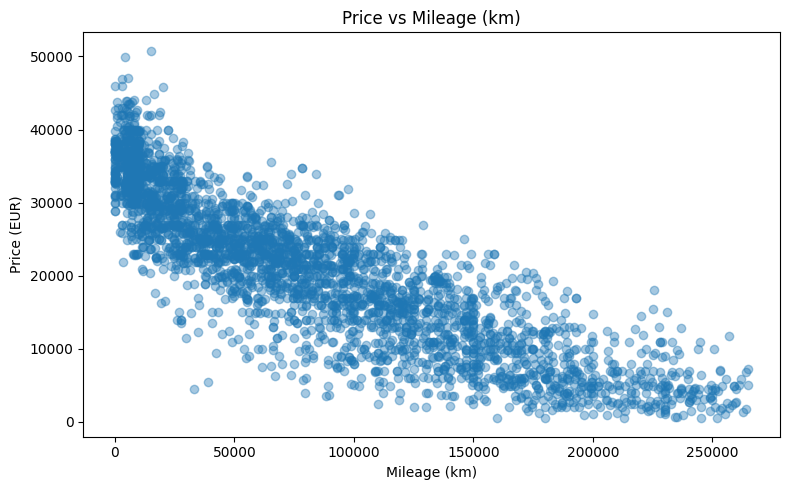

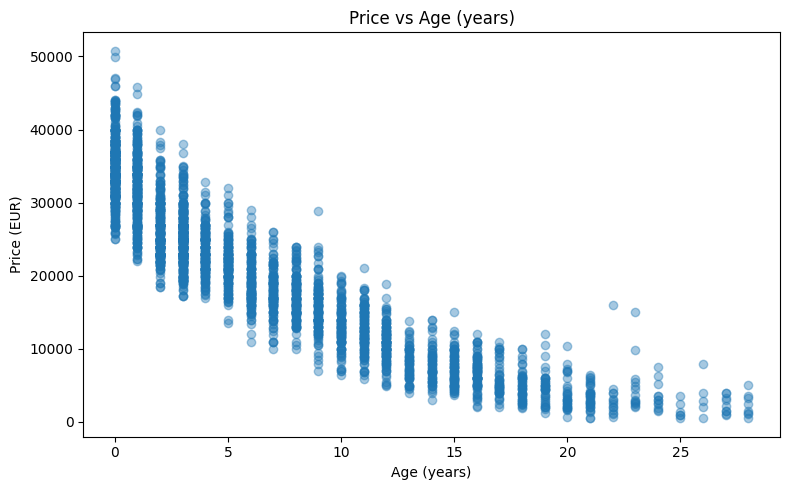

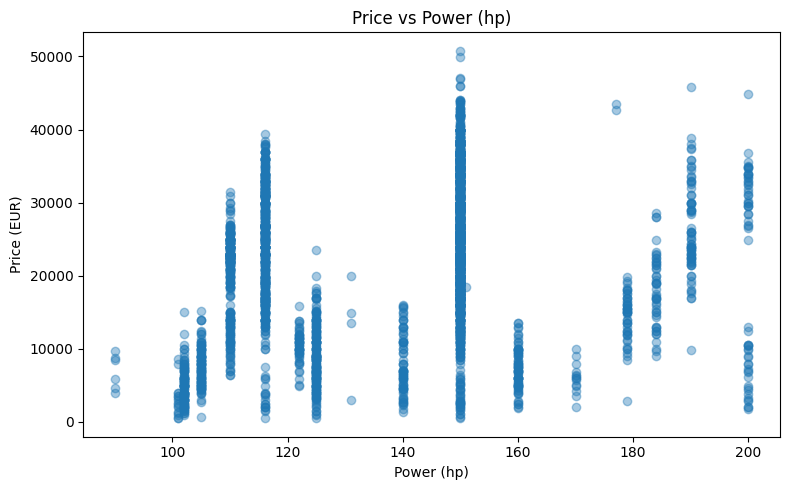

In [7]:
# Scatter: price vs mileage (sample for speed)
PLOT_MAX_POINTS = 20000
plot_df = df.sample(n=min(PLOT_MAX_POINTS, len(df)), random_state=RANDOM_SEED)

plot_feature_scatter(plot_df, 'mileage_km', 'Mileage (km)', REPORTS_DIR,
                     'scatter_price_vs_mileage_audi_a3_germany.png')

# Scatter: price vs age
plot_feature_scatter(plot_df, 'age_years', 'Age (years)', REPORTS_DIR,
                     'scatter_price_vs_age_audi_a3_germany.png')

# Scatter: price vs power
plot_feature_scatter(plot_df, 'power_hp', 'Power (hp)', REPORTS_DIR,
                     'scatter_price_vs_power_audi_a3_germany.png')


## Step 5 - Train/test split and baseline checks

We split the data so we can evaluate model performance on unseen examples.


In [8]:
# Features and target for modeling
X_mileage = df[['mileage_km']]
X_age = df[['age_years']]
X_power = df[['power_hp']]
X_multi = df[['mileage_km', 'age_years', 'power_hp']]
y = df['price_eur']

Xb_train, Xb_test, y_train, y_test = train_test_split(
    X_multi, y, test_size=0.2, random_state=RANDOM_SEED
)

print('Train size:', Xb_train.shape[0])
print('Test size:', Xb_test.shape[0])
print('Price summary (EUR):')
print(y.describe())


Train size: 2680
Test size: 670
Price summary (EUR):
count          3350.0
mean      21255.87791
std      10205.531633
min             500.0
25%          13412.25
50%           21992.5
75%           28940.0
max           50790.0
Name: price_eur, dtype: Float64


## Step 6 - Univariate regression: price ~ mileage

Univariate regression uses a single predictor. Here the coefficient is the expected change in price (EUR) for one additional kilometer of mileage.


In [9]:
# Fit and evaluate the model
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_mileage, y, test_size=0.2, random_state=RANDOM_SEED
)

model_mileage = LinearRegression()
model_mileage.fit(Xm_train, ym_train)

# Predictions
ym_pred_train = model_mileage.predict(Xm_train)
ym_pred_test = model_mileage.predict(Xm_test)

# Metrics
r2_train = r2_score(ym_train, ym_pred_train)
r2_test = r2_score(ym_test, ym_pred_test)
mae = mean_absolute_error(ym_test, ym_pred_test)
rmse = mean_squared_error(ym_test, ym_pred_test) ** 0.5

print("Intercept (EUR):", model_mileage.intercept_)
print("Coefficient (EUR per km):", model_mileage.coef_[0])
print("R2 train:", r2_train)
print("R2 test:", r2_test)
print("MAE test (EUR):", mae)
print("RMSE test (EUR):", rmse)



Intercept (EUR): 32328.09338256401
Coefficient (EUR per km): -0.13420405795208395
R2 train: 0.7525211896062212
R2 test: 0.737726439383156
MAE test (EUR): 4023.334240377502
RMSE test (EUR): 5230.987916908961


## Step 7 - Univariate regression: price ~ age

Here the coefficient is the expected change in price (EUR) for one additional year of age.


In [10]:
# Fit and evaluate the model
Xa_train, Xa_test, ya_train, ya_test = train_test_split(
    X_age, y, test_size=0.2, random_state=RANDOM_SEED
)

model_age = LinearRegression()
model_age.fit(Xa_train, ya_train)

# Predictions
ya_pred_train = model_age.predict(Xa_train)
ya_pred_test = model_age.predict(Xa_test)

# Metrics
r2_train = r2_score(ya_train, ya_pred_train)
r2_test = r2_score(ya_test, ya_pred_test)
mae = mean_absolute_error(ya_test, ya_pred_test)
rmse = mean_squared_error(ya_test, ya_pred_test) ** 0.5

print("Intercept (EUR):", model_age.intercept_)
print("Coefficient (EUR per year):", model_age.coef_[0])
print("R2 train:", r2_train)
print("R2 test:", r2_test)
print("MAE test (EUR):", mae)
print("RMSE test (EUR):", rmse)



Intercept (EUR): 30932.500592240016
Coefficient (EUR per year): -1518.9051774760972
R2 train: 0.8229965687203872
R2 test: 0.8033775073446645
MAE test (EUR): 3482.9344181125066
RMSE test (EUR): 4529.216277760745


In [11]:
# Fit and evaluate the model
Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_power, y, test_size=0.2, random_state=RANDOM_SEED
)

model_power = LinearRegression()
model_power.fit(Xp_train, yp_train)

# Predictions
yp_pred_train = model_power.predict(Xp_train)
yp_pred_test = model_power.predict(Xp_test)

# Metrics
r2_train = r2_score(yp_train, yp_pred_train)
r2_test = r2_score(yp_test, yp_pred_test)
mae = mean_absolute_error(yp_test, yp_pred_test)
rmse = mean_squared_error(yp_test, yp_pred_test) ** 0.5

print('Intercept (EUR):', model_power.intercept_)
print('Coefficient (EUR per hp):', model_power.coef_[0])
print('R2 train:', r2_train)
print('R2 test:', r2_test)
print('MAE test (EUR):', mae)
print('RMSE test (EUR):', rmse)


Intercept (EUR): 5225.503588188449
Coefficient (EUR per hp): 114.61473219600863
R2 train: 0.06570926879221495
R2 test: 0.06007391017788
MAE test (EUR): 8291.58676107093
RMSE test (EUR): 9902.692945814235


## Step 8 - Multivariate regression: price ~ mileage + age

Multivariate regression includes multiple predictors. Each coefficient shows the expected change in price while holding the other variable constant.


In [12]:
# Fit and evaluate the model
model_multi = LinearRegression()
model_multi.fit(Xb_train, y_train)

# Predictions
yb_pred_train = model_multi.predict(Xb_train)
yb_pred_test = model_multi.predict(Xb_test)

# Metrics
r2_train = r2_score(y_train, yb_pred_train)
r2_test = r2_score(y_test, yb_pred_test)
mae = mean_absolute_error(y_test, yb_pred_test)
rmse = mean_squared_error(y_test, yb_pred_test) ** 0.5

print('Intercept (EUR):', model_multi.intercept_)
print('Coefficient mileage (EUR per km):', model_multi.coef_[0])
print('Coefficient age (EUR per year):', model_multi.coef_[1])
print('Coefficient power (EUR per hp):', model_multi.coef_[2])
print('R2 train:', r2_train)
print('R2 test:', r2_test)
print('MAE test (EUR):', mae)
print('RMSE test (EUR):', rmse)


Intercept (EUR): 23390.532061863636
Coefficient mileage (EUR per km): -0.06392829304743042
Coefficient age (EUR per year): -929.5169489701539
Coefficient power (EUR per hp): 65.19290085418103
R2 train: 0.899485162124905
R2 test: 0.888064415111051
MAE test (EUR): 2540.496189190744
RMSE test (EUR): 3417.358547690732


## Step 9 - Compare models and interpret results

Univariate models show the raw relationship with price. The multivariate model adjusts each coefficient for the other variable.

R^2 shows the proportion of variance explained (higher is better). MAE and RMSE are error metrics in EUR; lower is better. RMSE penalizes large errors more than MAE.


In [13]:
# Compare models on the same test split
# Build a small comparison table
metrics = []

# Univariate mileage
ym_pred_test = model_mileage.predict(Xm_test)
metrics.append({
    'model': 'price ~ mileage',
    'r2_test': r2_score(ym_test, ym_pred_test),
    'mae_test': mean_absolute_error(ym_test, ym_pred_test),
    'rmse_test': mean_squared_error(ym_test, ym_pred_test) ** 0.5,
})

# Univariate age
ya_pred_test = model_age.predict(Xa_test)
metrics.append({
    'model': 'price ~ age',
    'r2_test': r2_score(ya_test, ya_pred_test),
    'mae_test': mean_absolute_error(ya_test, ya_pred_test),
    'rmse_test': mean_squared_error(ya_test, ya_pred_test) ** 0.5,
})

# Univariate power
yp_pred_test = model_power.predict(Xp_test)
metrics.append({
    'model': 'price ~ power',
    'r2_test': r2_score(yp_test, yp_pred_test),
    'mae_test': mean_absolute_error(yp_test, yp_pred_test),
    'rmse_test': mean_squared_error(yp_test, yp_pred_test) ** 0.5,
})

# Multivariate
yb_pred_test = model_multi.predict(Xb_test)
metrics.append({
    'model': 'price ~ mileage + age + power',
    'r2_test': r2_score(y_test, yb_pred_test),
    'mae_test': mean_absolute_error(y_test, yb_pred_test),
    'rmse_test': mean_squared_error(y_test, yb_pred_test) ** 0.5,
})

metrics_df = pd.DataFrame(metrics)
print(metrics_df)


                           model   r2_test     mae_test    rmse_test
0                price ~ mileage  0.737726  4023.334240  5230.987917
1                    price ~ age  0.803378  3482.934418  4529.216278
2                  price ~ power  0.060074  8291.586761  9902.692946
3  price ~ mileage + age + power  0.888064  2540.496189  3417.358548


## Step 10 - Predicted prices output
Confidence intervals describe uncertainty in the mean prediction. Prediction intervals are wider because they describe where a *new observation* is likely to fall.
We output the multivariate model predictions so they can be reused by other steps.


In [14]:
# Fit a final multivariate model on full data for prediction output
model_full = LinearRegression()
model_full.fit(X_multi, y)

# Predicted prices
predicted_price = model_full.predict(X_multi)

predictions_df = df[['listing_id']].copy()
predictions_df['predicted_price_eur'] = predicted_price

print(predictions_df.head())


   listing_id  predicted_price_eur
0          59         28513.910604
1         199         11812.411603
2         236         17732.440349
3         318         24352.356897
4         447         30677.794468


## Step 11 - Export labeled dataset for Session 7

We save the labeled dataset for logistic regression in Session 7.


In [15]:
# Write predicted prices to BigQuery (replace table)
pred_table = f"{project_id}.{dataset_id}.fact_price_predictions"

job_config = bigquery.LoadJobConfig(
    write_disposition='WRITE_TRUNCATE'
)
client.load_table_from_dataframe(predictions_df, pred_table, job_config=job_config).result()
print('Predictions table replaced:', pred_table)


c:\Users\cfuen\OneDrive\Documentos\Clases\Ficheros para clase\Albert\Head of Data 101\Github repo\HeadOfData101\.venv\Lib\site-packages\google\cloud\bigquery\_pandas_helpers.py:484: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Predictions table replaced: albertheadofdata101.autoscout_audi_a3_germany.fact_price_predictions


## Step 11 - Save predicted prices to BigQuery
We overwrite the `fact_price_predictions` table with current results for the selected scope.


## Step 12 - Summary and next steps
We scoped the data to a single make/model, fit univariate and multivariate regressions, and generated predicted prices using the multivariate model.
### What you should reuse next session
- The predicted price output table in BigQuery.
- The same feature columns (`mileage_km`, `age_years`) and scope filters.
